# Hälsostudie
Analysen av datan från hälsostudien inleds med en översikt av datan, kvalitetsgranskning och städning. 

För en inledande visulaisering av data valdes ett histogram över systoliskt blodtryck, en boxplot som visar fördelning av vikt per kön, andelen rökare vs ickerökare per åldersgrupp och andelen sjuka vs icke sjuka per åldersgrupp.  

Andelen sjuka totalt i urvalet studerades vidare genom att jämföra med en simulering baserad på samma sannolikhet som den observerade. Resultatet av detta visar att deras respektive konfidensintervall tydligt överlappar. Detta innebär att de inte skiljer sig statistiskt vilket indikerar att den observerade andelen sjuka kan vara representativ för populationen. 
 
Data för systoliskt blodtryck studerades med normalapproximation och Bootstrap. resultaten visar att deras medelvärde och konfidensintervall är lika vilket indikerar att data för systoliskt blodtryck är normalfördelad. Detta innebär t-test kan användas för att jämföra medelvärden mellan grupper.  

T-test visar att det inte finns någon signifikant skillnad mellan medelvärdet av systoliskt blodtryck mellan gruppen rökare och icke-rökare.  
Både standard t-test och Welch-test visar liknande resultat vilket stödjer detta. Eftersom p > 0,05 så kan inte nollhypotesen förkastas.  

För att studera om det praktiskt finns en skillnad beräknades effektstorleken med Cohen's d. Resultatet är under 0,2 vilket visar på en liten effekt och stödjer t-testets resultat att det inte är en signifikant skillnad mellan gruppernas medelvärden. D är positivt vilket indikerar att rökare har ett högre systoliskt blodtryck än icke-rökare. Då skillnaden inte är signifikant och effekten liten så går det inte att säga utifrån datan att rökning har en påverkan på systoliskt blodtryck. 

En simulering resulterade i en power på 7,3% för hypotestestet vilket indikerar att hypotestestet inte är så säkert.  
Den analytiska beräkningen av storleken på urval visar att med den effekt som observerats så skulle utvalet behöva vara ca 30 000 för att uppnå en power på 80%.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from sklearn.linear_model import LinearRegression

import src.io_utils as io
import src.health_study as H
import src.metrics as M
from src.metrics import HealthAnalyzer
from src.metrics import MeanCIAnalyzer
from src.metrics import SmokerAnalyzer
from src.metrics import BPAnalyzer
import src.viz as V

np.random.seed(42)

In [3]:
df = io.df

display(df.head())
display(df.info())
display(df.describe().round(3))

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


None

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.000,800.000,800.000,800.000,800.000,800.000,800.000
mean,400.500,49.426,171.849,73.413,149.179,4.929,0.059
std,231.084,14.501,9.804,13.685,12.793,0.848,0.235
min,1.000,18.000,144.400,33.700,106.800,2.500,0.000
25%,200.750,39.000,164.775,64.800,140.900,4.328,0.000
50%,400.500,50.000,171.350,73.200,149.400,4.970,0.000
75%,600.250,59.000,178.925,82.600,157.600,5.482,0.000
max,800.000,90.000,200.400,114.400,185.900,7.880,1.000


In [4]:
print("Antal saknade värden per kolumn:")
qc = H.quality_check(df)
display(qc["nan_count"])
print(f"\nAntal dubletter: {H.quality_check(df)['dup_count']}")
print("\nAntal ogiltiga värden:")
display(qc["invalid_summary"])

Antal saknade värden per kolumn:


id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64


Antal dubletter: 0

Antal ogiltiga värden:


,Kolumn,Antal ogiltiga
0,disease,0
1,sex,0
2,smoker,0


In [5]:
df_clean = H.clean_data(df)

In [ ]:
print("Sammanfattande statistik")
M.summary_stats(df_clean)

In [ ]:
fig, axes = V.overview_grid(df_clean)
plt.show()

In [ ]:
analyzer = HealthAnalyzer(df_clean)

p_obs = analyzer.observed()
print(f"Andel observerat sjuka: {p_obs*100:.1f}%")

p_sim = analyzer.simulated()
print(f"Andel simulerat sjuka: {p_sim*100:.1f}%")

summary_compare = analyzer.compare()
display(summary_compare)

analyzer.plot_compare(summary_compare)
plt.show()

#### Andel sjuka vs icke sjuka  
En simulering baserad på samma sannolikhet som den observerade visar att deras respektive konfidensintervall överlappar tydligt.  
Detta innebär att de inte skiljer sig statistiskt vilket indikerar att den observerade andelen sjuka kan vara representativ för populationen.

In [ ]:
A = MeanCIAnalyzer(df_clean["systolic_bp"], name="Systoliskt blodtryck")
nlo, nhi, nmean, s, n = A.ci_mean_normal()
print(f"Normal medelvärde: {nmean:.6f}")
print(f"Normal 95% konfidensintervall: [{nlo:.2f}, {nhi:.2f}]")

blo, bhi, bmean = A.ci_mean_bootstrap(B=5000)
print(f"\nBootstrap medelvärde: {bmean:.6f}")
print(f"Bootstrap 95% KI: [{blo:.2f}, {bhi:.2f}]")

A.plot_compare(nlo, nhi, nmean, blo, bhi, bmean)
plt.show()

#### Konfidensintervall för medelvärde systoliskt blodtryck
Normal medelvärde: 149.178625   
Bootstrap medel: 149.178625   
Normal 95% konfidensintervall: [148.29, 150.07]  
Bootstrap 95% konfidensintervall: [148.31, 150.04]  

Medelvärdet och konfidensintervallet med normalapproximation och Bootstrap är mycket lika vilket indikerar att data för systoliskt blodtryck är normalfördelad.  
Detta innebär t-test kan användas för att jämföra medelvärden mellan grupper.

In [ ]:
A = SmokerAnalyzer(df_clean)

print(f"Medelvärden ({A.value_col}):")
print(f"Rökare: {A.mean_rökare:.2f} ± {A.std_rökare:.2f}")
print(f"Icke-rökare: {A.mean_ickerökare:.2f} ± {A.std_ickerökare:.2f}\n")

t_stat, p_val, t_stat_w, p_val_w = A.ttests()
print("T-testresultat:")
print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}") 
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")

d = A.cohens_d()
print(f"Cohen's d: {d:.4f}")

A.power_simulation()
print(f"Power (simulerad) i hypotestestet ≈ {A.power_sim*100:.1f}%")

A.power_analytical()
print(f"Power (analytisk) i hypotestestet: {A.power_ana*100:.1f}%")

A.power_n_required()
print(f"N som krävs i gruppen icke rökare för 80% power: {np.ceil(A.n_needed):.0f} (rökare ≈ {np.ceil(A.n_needed*A.ratio):.0f})")

fig, ax = A.plot_sample_size_power()
plt.show()

In [ ]:
A = SmokerAnalyzer(df_clean, value_col="cholesterol")

print(f"Medelvärden ({A.value_col}):")
print(f"Rökare: {A.mean_rökare:.2f} ± {A.std_rökare:.2f}")
print(f"Icke-rökare: {A.mean_ickerökare:.2f} ± {A.std_ickerökare:.2f}\n")

t_stat, p_val, t_stat_w, p_val_w = A.ttests()
print("T-testresultat:")
print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}") 
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")

d = A.cohens_d()
print(f"Cohen's d: {d:.4f}")

A.power_simulation()
print(f"Power (simulerad) i hypotestestet ≈ {A.power_sim*100:.1f}%")

A.power_analytical()
print(f"Power (analytisk) i hypotestestet: {A.power_ana*100:.1f}%")

A.power_n_required()
print(f"N som krävs i gruppen icke rökare för 80% power: {np.ceil(A.n_needed):.0f} (rökare ≈ {np.ceil(A.n_needed*A.ratio):.0f})")

fig, ax = A.plot_sample_size_power()
plt.show()

In [ ]:
A = SmokerAnalyzer(df_clean, value_col="age")

print(f"Medelvärden ({A.value_col}):")
print(f"Rökare: {A.mean_rökare:.2f} ± {A.std_rökare:.2f}")
print(f"Icke-rökare: {A.mean_ickerökare:.2f} ± {A.std_ickerökare:.2f}\n")

t_stat, p_val, t_stat_w, p_val_w = A.ttests()
print("T-testresultat:")
print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}") 
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")

d = A.cohens_d()
print(f"Cohen's d: {d:.4f}")

A.power_simulation()
print(f"Power (simulerad) i hypotestestet ≈ {A.power_sim*100:.1f}%")

A.power_analytical()
print(f"Power (analytisk) i hypotestestet: {A.power_ana*100:.1f}%")

A.power_n_required()
print(f"N som krävs i gruppen icke rökare för 80% power: {np.ceil(A.n_needed):.0f} (rökare ≈ {np.ceil(A.n_needed*A.ratio):.0f})")

fig, ax = A.plot_sample_size_power()
plt.show()

Linjär ekvation: ŷ = 122.68 + 0.54 * x
Förklaringsgrad (R²): 0.369


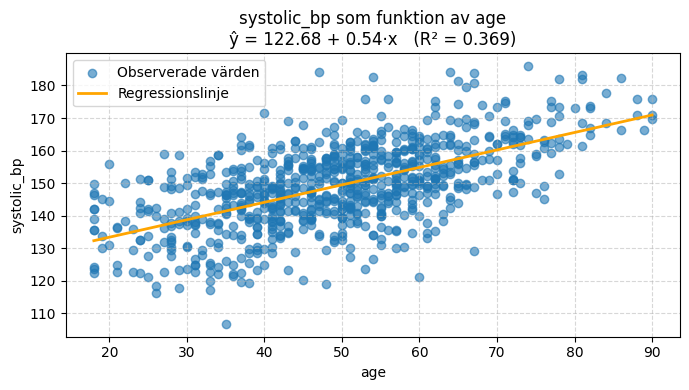

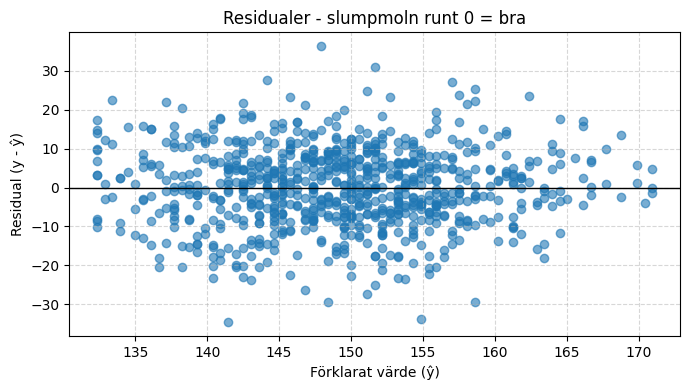

Prognos systoliskt blodtryck vid 40 års ålder: 144.13
Prognos systoliskt blodtryck vid 60 års ålder: 154.85
Prognos systoliskt blodtryck vid 80 års ålder: 165.57


In [8]:
A = BPAnalyzer(df_clean, x_col="age", y_col="systolic_bp")

print(f"Linjär ekvation: ŷ = {A.intercept:.2f} + {A.slope:.2f} * x")
print(f"Förklaringsgrad (R²): {A.r2:.3f}")

fig, ax = A.plot_model()
plt.show()

fig, ax = A.plot_residuals()
plt.show()

pre_40 = A.prediction([40])[0]
print(f"Prognos systoliskt blodtryck vid 40 års ålder: {pre_40:.2f}")
pre_60 = A.prediction([60])[0]
print(f"Prognos systoliskt blodtryck vid 60 års ålder: {pre_60:.2f}")
pre_80 = A.prediction([80])[0]
print(f"Prognos systoliskt blodtryck vid 80 års ålder: {pre_80:.2f}")